In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.model_selection import cross_val_score, ParameterGrid
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

# Data Processing

In [ ]:
match_df = pd.read_csv("match_data.csv")
# To ensure time order
match_df.loc[:, 'match_start_datetime'] = pd.to_datetime(match_df['match_start_datetime'], format='%Y-%m-%d %H:%M:%S')
match_df = match_df.sort_values(['match_start_datetime', 'fixture_id', 'halftime', 'minute', 'second'])
match_df.head()

,fixture_id,halftime,current_time,half_start_datetime,match_start_datetime,minute,second,latest_bookmaker_update,suspended,stopped,...,Throwins - home,Total Crosses - away,Total Crosses - home,Yellowcards - away,Yellowcards - home,Yellowred Cards - away,Yellowred Cards - home,current_state,final_score,result
0,19172016.0,1st-half,2024-08-09 18:11:36,2024-08-09 18:01:37,2024-08-09 18:01:37,9,59,2024-08-09 18:11:28,False,False,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,X,2-1,1
1,19172016.0,1st-half,2024-08-09 18:27:30,2024-08-09 18:01:37,2024-08-09 18:01:37,25,53,2024-08-09 18:27:24,False,False,...,11.0,1.0,12.0,0.0,0.0,0.0,0.0,X,2-1,1
2,19172016.0,1st-half,2024-08-09 18:28:25,2024-08-09 18:01:37,2024-08-09 18:01:37,26,48,2024-08-09 18:28:20,False,False,...,11.0,1.0,13.0,0.0,0.0,0.0,0.0,X,2-1,1
3,19172016.0,1st-half,2024-08-09 18:29:32,2024-08-09 18:01:37,2024-08-09 18:01:37,27,55,2024-08-09 18:29:28,False,False,...,11.0,1.0,13.0,0.0,0.0,0.0,0.0,X,2-1,1
4,19172016.0,1st-half,2024-08-09 18:30:37,2024-08-09 18:01:37,2024-08-09 18:01:37,29,0,2024-08-09 18:30:32,True,False,...,11.0,1.0,14.0,0.0,0.0,0.0,0.0,X,2-1,1


In [ ]:
match_df.loc[[650, 651]][['Redcards - home', '1', 'X', '2']]

,Redcards - home,1,X,2
650,0.0,2.20,3.0,3.75
651,1.0,4.33,3.1,2.00


Odds account for the events directly, so we can use them for the same minute.

In [ ]:
# Forward fill with time order
match_val_cols = match_df.columns[7:]
# Since the data already sorted
match_filled_df = match_df.groupby(['fixture_id'])[match_val_cols].ffill()
match_filled_df = match_filled_df.sort_index()

# Fill remaining (initial) values with 0
match_filled_df = match_filled_df.fillna(0)

match_df.loc[:, match_val_cols] = match_filled_df

In [ ]:
# Drop unusable odd points
usable_odd_mask = (match_df['suspended'].astype(int) + match_df['stopped'].astype(int)) == 0
match_odd_df = match_df[usable_odd_mask].copy()

In [ ]:
# Q1
match_odd_df['P(1)_v1'] = 1/match_odd_df['1']
match_odd_df['P(X)_v1'] = 1/match_odd_df['X']
match_odd_df['P(2)_v1'] = 1/match_odd_df['2']

In [ ]:
# Q2
match_total_prob = 1/match_odd_df['1'] + 1/match_odd_df['X'] + 1/match_odd_df['2']
match_odd_df['P(1)_norm'] = (1/match_odd_df['1']) * (1/match_total_prob)
match_odd_df['P(X)_norm'] = 1/match_odd_df['X'] * (1/match_total_prob)
match_odd_df['P(2)_norm'] = 1/match_odd_df['2'] * (1/match_total_prob)

In [ ]:
# Check available match lengths
match_odd_df['abs_minute'] = match_odd_df['minute'] + np.where(match_odd_df['halftime']=='1st-half', 0, 45)
match_odd_df.groupby('fixture_id')['abs_minute'].max().sort_values()

fixture_id
19135346.0      6
19139689.0     24
19155103.0     26
19155147.0     28
19134518.0     31
             ... 
19134532.0    101
19172104.0    103
19134507.0    103
19135296.0    104
19135321.0    117
Name: abs_minute, Length: 648, dtype: int64

In [ ]:
# Drop short matches
match_last_min = match_odd_df.groupby('fixture_id')['abs_minute'].max()
short_fix_arr = match_last_min[match_last_min < 40]
match_odd_df = match_odd_df[~match_odd_df['fixture_id'].isin(short_fix_arr)]

In [ ]:
match_odd_df['home_name'] = match_odd_df['name'].str.split(' vs ').str[0]
match_odd_df['away_name'] = match_odd_df['name'].str.split(' vs ').str[1]

In [ ]:
unique_teams = np.unique(match_odd_df['home_name'].tolist() + match_odd_df['away_name'].tolist())
unique_dates = match_odd_df['match_start_datetime'].unique()

In [ ]:
prev_k = 2
interested_cols = pd.Index([f'Shots On Target - team_prev_{prev_k}', f'Corners - team_prev_{prev_k}',
                            f'Goals - team_prev_{prev_k}', f'Streak - team_prev_{prev_k}', f'Weighted Streak - team_prev_{prev_k}'])

In [ ]:
# Create features about previous matches; minimum 2, 3 if available
def get_team_features(x, team_type='home'):
    team = x[team_type + '_name']
    match_date = x['match_start_datetime']

    # Match df as home team
    team_home_df = match_odd_df[(match_odd_df['home_name']==team) & (match_odd_df['match_start_datetime'] < match_date)].copy()
    team_home_df.columns = team_home_df.columns.str.replace('away', 'opposite')
    team_home_df.columns = team_home_df.columns.str.replace('home', 'team')
    # Streak points
    team_home_df.loc[:, 'result'] = team_home_df['result'].str.replace('1', '3')
    team_home_df.loc[:, 'result'] = team_home_df['result'].str.replace('X', '1')
    team_home_df.loc[:, 'result'] = team_home_df['result'].str.replace('2', '0')

    # Match df as away team
    team_away_df = match_odd_df[(match_odd_df['away_name']==team)  & (match_odd_df['match_start_datetime'] < match_date)].copy()
    team_away_df.columns = team_away_df.columns.str.replace('away', 'team')
    team_away_df.columns = team_away_df.columns.str.replace('home', 'opposite')
    # Streak points
    team_away_df.loc[:, 'result'] = team_away_df['result'].str.replace('1', '0')
    team_away_df.loc[:, 'result'] = team_away_df['result'].str.replace('X', '1')
    team_away_df.loc[:, 'result'] = team_away_df['result'].str.replace('2', '3')

    team_prev_df = pd.concat((team_home_df, team_away_df), ignore_index=True)
    if team_prev_df['fixture_id'].nunique() < prev_k:
        return None
    else:
        loc_cols = interested_cols.str.replace('team_prev_2', 'team')[:-1]
        last_k_fix = team_prev_df['fixture_id'].unique()[-3:]

        team_prev_df = team_prev_df[team_prev_df['fixture_id'].isin(last_k_fix)]
        team_prev_df.loc[:, 'result'] = team_prev_df['result'].astype(float)
        team_prev_df = team_prev_df.rename({'result': 'Streak - team'}, axis=1)
        team_prev_df = team_prev_df.groupby('fixture_id')[loc_cols].max()

        # Calculate weighted streak
        n_matches = len(team_prev_df)
        weight_arr = np.arange(1, n_matches + 1)
        weighted_streak = (team_prev_df['Streak - team'] * weight_arr).sum() / (3 * n_matches * (n_matches + 1))

        # Take average of other metrics
        team_stat_ser = team_prev_df.mean()
        team_stat_ser['Weighted Streak - team'] = weighted_streak
        team_stat_ser.index = team_stat_ser.index.str.replace('team', f'{team_type}_prev_2')

        return team_stat_ser

In [ ]:
# Calculate features for the first minute of matches
home_prev_df = match_odd_df.drop_duplicates(subset=['fixture_id']).iloc[::-1].apply(get_team_features, team_type='home', axis=1)
home_prev_df = home_prev_df.dropna()

away_prev_df = match_odd_df.drop_duplicates(subset=['fixture_id']).iloc[::-1].apply(get_team_features, team_type='away', axis=1)
away_prev_df = away_prev_df.dropna()

In [ ]:
team_form_df = pd.DataFrame(index=unique_dates, columns=unique_teams)
team_form_df.iloc[0, :] = 1
step = 0.1
for i, date in enumerate(unique_dates):
    if i == len(unique_dates)-1:
        break
    # Update next date
    loc_date = team_form_df.iloc[[i + 1]].index
    date_match_df = match_odd_df[match_odd_df['match_start_datetime']==date]
    fixture_arr = date_match_df['fixture_id'].unique()
    for fix in fixture_arr:
        date_fix_df = date_match_df[date_match_df['fixture_id']==fix]
        home_team = date_fix_df['home_name'].unique()[0]
        away_team = date_fix_df['away_name'].unique()[0]
        result = date_fix_df['result'].unique()[0]

        # In each date, update the next date's team forms based on the played matches
        if result == 'X':
            team_form_df.loc[loc_date, home_team] = team_form_df.loc[date, home_team]\
                - step * (team_form_df.loc[date, home_team] - team_form_df.loc[date, away_team])

            team_form_df.loc[loc_date, away_team] = team_form_df.loc[date, away_team]\
                - step * (team_form_df.loc[date, away_team] - team_form_df.loc[date, home_team])
        elif result == '1':
            team_form_df.loc[loc_date, home_team] = team_form_df.loc[date, home_team]\
                + step * team_form_df.loc[date, away_team]
            team_form_df.loc[loc_date, away_team] = team_form_df.loc[date, away_team]\
                - step * team_form_df.loc[date, away_team]
        elif result == '2':
            team_form_df.loc[loc_date, home_team] = team_form_df.loc[date, home_team]\
                - step * team_form_df.loc[date, home_team]
            team_form_df.loc[loc_date, away_team] = team_form_df.loc[date, away_team]\
                + step * team_form_df.loc[date, home_team]

    # Fill with previous date if team not played any match
    team_form_df.iloc[:i+2] = team_form_df.iloc[:i+2].ffill()

team_form_df

,AFC Bournemouth,Adana Demirspor,Alanyaspor,Angers SCO,Antalyaspor,Arsenal,Aston Villa,Atalanta,Athletic Club,Atlético Madrid,...,Valencia,Venezia,VfB Stuttgart,VfL Bochum 1848,VfL Wolfsburg,Villarreal,Werder Bremen,West Ham United,Wolverhampton Wanderers,İstanbul Başakşehir
2024-08-09 18:01:37,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-10 16:15:40,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-10 18:44:33,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-10 18:45:14,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-11 18:46:49,1.0,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-10 17:32:41,1.068745,0.431239,0.698833,0.874852,0.773738,1.202148,1.004322,1.471661,1.061222,1.404312,...,0.697088,0.606434,0.937034,0.510354,0.812557,1.287676,1.039859,0.818559,0.640918,1.001496
2024-11-10 18:30:18,1.068745,0.431239,0.698833,0.874852,0.773738,1.202148,1.004322,1.471661,1.061222,1.404312,...,0.697088,0.606434,0.937034,0.510354,0.812557,1.287676,1.039859,0.818559,0.640918,1.001496
2024-11-10 19:45:13,1.068745,0.431239,0.698833,0.874852,0.773738,1.202148,1.004322,1.471661,1.061222,1.404312,...,0.697088,0.606434,0.937034,0.510354,0.890184,1.287676,1.039859,0.818559,0.640918,1.001496
2024-11-10 19:46:34,1.068745,0.431239,0.698833,0.874852,0.773738,1.202148,1.004322,1.471661,1.061222,1.404312,...,0.697088,0.606434,0.937034,0.510354,0.890184,1.287676,1.039859,0.818559,0.640918,1.001496


In [ ]:
def get_match_forms(x):
    # Get team form features, to return df with apply
    home_team = x['home_name']
    away_team = x['away_name']
    match_date = x['match_start_datetime']

    home_form = team_form_df.loc[match_date, home_team]
    away_form = team_form_df.loc[match_date, away_team]
    return pd.Series({'home_form': home_form, 'away_form': away_form})

In [ ]:
# Find forms for the first minute of matches
team_form_df = match_odd_df.drop_duplicates(subset=['fixture_id']).iloc[::-1].apply(get_match_forms, axis=1)

In [ ]:
match_odd_df['goal_diff'] = match_odd_df['Goals - home'] - match_odd_df['Goals - away']

# Area knowledge features, proposed by Burak
team_type_arr = ['home', 'away']
for team in team_type_arr:
    match_odd_df[f'shot_efficiency_{team}'] = match_odd_df[f'Goals - {team}'] / match_odd_df[f'Shots Total - {team}']

    match_odd_df[f'cross_rate_{team}'] = match_odd_df[f'Accurate Crosses - {team}'] / match_odd_df[f'Total Crosses - {team}']

    match_odd_df[f'cls_sh_rate_{team}'] = match_odd_df[f'Shots Insidebox - {team}'] / match_odd_df[f'Shots Total - {team}']

    match_odd_df[f'attack_score_{team}'] = (match_odd_df[f'Dangerous Attacks - {team}']
                                            + match_odd_df[f'Goal Attempts - {team}'] * 2
                                            + match_odd_df[f'Successful Dribbles - {team}'] * 0.5) / 3.5

    match_odd_df[f'defense_score_{team}'] = (match_odd_df[f'Tackles - {team}']
                                            + match_odd_df[f'Interceptions - {team}']
                                            + match_odd_df[f'Shots Blocked - {team}']) / 3

    match_odd_df[f'atc_def_ratio_{team}'] = match_odd_df[f'attack_score_{team}'] / (match_odd_df[f'defense_score_{team}']+0.01)

    match_odd_df[f'expected_goals_{team}'] = (match_odd_df[f'Shots On Target - {team}'] * 0.3
                                            + match_odd_df[f'Shots Insidebox - {team}'] * 0.15
                                            + match_odd_df[f'Shots Outsidebox - {team}'] * 0.05)

    match_odd_df[f'game_pressure_{team}'] = (match_odd_df[f'Corners - {team}'] * 0.1
                                            + match_odd_df[f'Free Kicks - {team}'] * 0.2
                                            + match_odd_df[f'Penalties - {team}'] * 0.7)

    match_odd_df[f'mntl_moment_{team}'] = (match_odd_df[f'Goals - {team}']
                                            - match_odd_df[f'Redcards - {team}']
                                            - match_odd_df[f'Injuries - {team}'] * 0.5)

In [ ]:
# Odd & percentage features are normalized already
continuous_feature_arr = match_df.columns[match_df.dtypes == 'float64'][4:]
percent_feature_arr = continuous_feature_arr[continuous_feature_arr.str.lower().str.contains('percentage|%')]
continuous_feature_arr = continuous_feature_arr[~continuous_feature_arr.isin(percent_feature_arr)]
percent_feature_arr

Index(['Ball Possession % - away', 'Ball Possession % - home',
       'Successful Passes Percentage - away',
       'Successful Passes Percentage - home'],
      dtype='object')

In [ ]:
unique_cont_feature_arr = continuous_feature_arr.str[:-7].unique()
print('All continuous(wo percentage):', len(continuous_feature_arr), ' Unique:', len(unique_cont_feature_arr))
unique_cont_feature_arr

All continuous(wo percentage): 84  Unique: 42


Index(['Accurate Crosses', 'Assists', 'Attacks', 'Ball Safe', 'Challenges',
       'Corners', 'Counter Attacks', 'Dangerous Attacks', 'Dribble Attempts',
       'Fouls', 'Free Kicks', 'Goal Attempts', 'Goal Kicks', 'Goals',
       'Headers', 'Hit Woodwork', 'Injuries', 'Interceptions', 'Key Passes',
       'Long Passes', 'Offsides', 'Passes', 'Penalties', 'Redcards', 'Saves',
       'Score Change', 'Shots Blocked', 'Shots Insidebox', 'Shots Off Target',
       'Shots On Target', 'Shots Outsidebox', 'Shots Total', 'Substitutions',
       'Successful Dribbles', 'Successful Headers', 'Successful Interceptions',
       'Successful Passes', 'Tackles', 'Throwins', 'Total Crosses',
       'Yellowcards', 'Yellowred Cards'],
      dtype='object')

In [ ]:
# Add home/total feature ratios
match_feature_df = match_odd_df.copy()
for feature in unique_cont_feature_arr:
    resp_feature_arr = continuous_feature_arr[continuous_feature_arr.str.contains(feature)]
    resp_perc_ser = match_feature_df[resp_feature_arr[0]] / match_feature_df[resp_feature_arr].sum(axis=1).values
    match_feature_df[feature + ' - ratio'] = resp_perc_ser

In [ ]:
# Forward fill to fill previous match and form features of respective fixture rows after the first one
X_df = match_feature_df.join(home_prev_df).join(away_prev_df).join(team_form_df).ffill()
X_df = X_df[X_df['abs_minute'] > 10]
X_df

,fixture_id,halftime,current_time,half_start_datetime,match_start_datetime,minute,second,latest_bookmaker_update,suspended,stopped,...,Goals - home_prev_2,Streak - home_prev_2,Weighted Streak - home_prev_2,Shots On Target - away_prev_2,Corners - away_prev_2,Goals - away_prev_2,Streak - away_prev_2,Weighted Streak - away_prev_2,home_form,away_form
1,19172016.0,1st-half,2024-08-09 18:27:30,2024-08-09 18:01:37,2024-08-09 18:01:37,25,53,2024-08-09 18:27:24,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
2,19172016.0,1st-half,2024-08-09 18:28:25,2024-08-09 18:01:37,2024-08-09 18:01:37,26,48,2024-08-09 18:28:20,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
3,19172016.0,1st-half,2024-08-09 18:29:32,2024-08-09 18:01:37,2024-08-09 18:01:37,27,55,2024-08-09 18:29:28,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
8,19172016.0,1st-half,2024-08-09 18:34:18,2024-08-09 18:01:37,2024-08-09 18:01:37,32,41,2024-08-09 18:34:12,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
9,19172016.0,1st-half,2024-08-09 18:35:27,2024-08-09 18:01:37,2024-08-09 18:01:37,33,50,2024-08-09 18:35:26,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63937,19135376.0,2nd-half,2024-11-10 21:51:41,2024-11-10 21:06:59,2024-11-10 20:02:05,44,42,2024-11-10 21:51:37,False,False,...,1.333333,2.333333,0.444444,6.0,4.0,2.666667,2.0,0.416667,0.977239,1.985594
63938,19135376.0,2nd-half,2024-11-10 21:52:41,2024-11-10 21:06:59,2024-11-10 20:02:05,45,42,2024-11-10 21:52:37,False,False,...,1.333333,2.333333,0.444444,6.0,4.0,2.666667,2.0,0.416667,0.977239,1.985594
63939,19135376.0,2nd-half,2024-11-10 21:53:41,2024-11-10 21:06:59,2024-11-10 20:02:05,46,42,2024-11-10 21:53:35,False,False,...,1.333333,2.333333,0.444444,6.0,4.0,2.666667,2.0,0.416667,0.977239,1.985594
63940,19135376.0,2nd-half,2024-11-10 21:54:41,2024-11-10 21:06:59,2024-11-10 20:02:05,47,42,2024-11-10 21:54:36,False,False,...,1.333333,2.333333,0.444444,6.0,4.0,2.666667,2.0,0.416667,0.977239,1.985594


In [ ]:
X_df.isna().sum().sort_values().tail(20)

Yellowcards - ratio                19
Score Change - ratio               30
Penalties - ratio                  30
Long Passes - ratio                32
Headers - ratio                   353
Successful Headers - ratio        353
Redcards - ratio                  396
Yellowred Cards - ratio           408
Counter Attacks - ratio           574
Free Kicks - ratio                765
Shots On Target - home_prev_2    4309
Corners - home_prev_2            4309
Goals - home_prev_2              4309
Streak - home_prev_2             4309
Weighted Streak - home_prev_2    4309
Shots On Target - away_prev_2    4309
Corners - away_prev_2            4309
Goals - away_prev_2              4309
Streak - away_prev_2             4309
Weighted Streak - away_prev_2    4309
dtype: int64

In [ ]:
# Not needed columns in the modelling
drop_cols = X_df.columns[:15]
drop_cols = drop_cols[drop_cols!='match_start_datetime']
drop_cols = drop_cols.tolist() + ['current_state', 'final_score', 'home_name', 'away_name']

# V1: Not using provided odd information
drop_cols_v1 = drop_cols + [f'P({i})_v1' for i in [1, 'X', 2]] + ['1', 'X', '2'] + [f'P({i})_norm' for i in [1, 'X', 2]]
print(drop_cols_v1)

['fixture_id', 'halftime', 'current_time', 'half_start_datetime', 'minute', 'second', 'latest_bookmaker_update', 'suspended', 'stopped', '1', '2', 'X', 'name', 'ticking', 'current_state', 'final_score', 'home_name', 'away_name']


In [ ]:
(X_df.drop(drop_cols, axis=1) == np.inf).sum().sort_values().tail(6)

away_form                0
cross_rate_home          1
shot_efficiency_home    29
cls_sh_rate_home        34
cls_sh_rate_away        71
shot_efficiency_away    81
dtype: int64

In [ ]:
X_df = X_df[~(X_df == np.inf).any(axis=1)]

In [ ]:
# Seperate test data
test_df = X_df[X_df['match_start_datetime'] >= '2024-11-01']
X_df = X_df.drop(test_df.index)

In [ ]:
X_df['match_start_datetime'].astype(str).str.split().str[0].nunique()

50

# Modelling

## Classification

In [ ]:
def ranked_probability_score(y_true, y_pred, class_mapping):
    # Calculate RPS given true values, predicted probabilities and class mapping
    n_classes = y_pred.shape[1]
    y_true_temp = np.array([class_mapping[label] for label in y_true])

    # Change shape of true values by encoding
    y_true_one_hot = np.zeros_like(y_pred)
    y_true_one_hot[np.arange(len(y_true_temp)), y_true_temp] = 1

    y_true_cumsum = np.cumsum(y_true_one_hot, axis=1)
    y_pred_cumsum = np.cumsum(y_pred, axis=1)

    rps = np.sum((y_true_cumsum - y_pred_cumsum) ** 2, axis=1) / (n_classes - 1)
    return np.mean(rps)

In [ ]:
def cv_rps_perf(cv_df, model, cand_params, target_col, datetime_col, min_train_days=30):
    """
    Perform TS CV based on days, evaluate model performance with RPS.
    """
    cv_df = cv_df.sort_values(by=datetime_col)

    # Find unique dates
    unique_dates = sorted(cv_df[datetime_col].dt.date.unique())

    parameter_grid = ParameterGrid(cand_params)
    param_val_df = pd.DataFrame(columns=['n_estimators', 'max_depth', 'min_samples_leaf',
                                         'max_features', 'Test_RPS_Mean', 'Train_RPS_Mean'])
    # Iterate over each parameter set
    for a, params in enumerate(parameter_grid):
        # Set the model parameters
        model.set_params(**params)

        test_rps_scores = []
        train_rps_scores = []
        for i in range(min_train_days, len(unique_dates), 5):
            # Define training and test periods
            train_dates = unique_dates[:i]
            # Use all dates after the training set
            test_dates = unique_dates[i:]

            train_data = cv_df[cv_df[datetime_col].dt.date.isin(train_dates)]
            test_data = cv_df[cv_df[datetime_col].dt.date.isin(test_dates)]
            X_train, y_train = train_data.drop(columns=[target_col, datetime_col]), train_data[target_col]
            X_test, y_test = test_data.drop(columns=[target_col, datetime_col]), test_data[target_col]

            # Train the model
            model.fit(X_train, y_train)
            model_classes = model.classes_
            class_mapping = {model_classes[0]: 0, model_classes[1]: 1, model_classes[2]: 2}

            # Calculate iteration RPS metrics
            y_test_pred = model.predict_proba(X_test)
            test_rps = ranked_probability_score(y_test.values, y_test_pred, class_mapping)
            test_rps_scores.append(test_rps)

            y_train_pred = model.predict_proba(X_train)
            train_rps = ranked_probability_score(y_train.values, y_train_pred, class_mapping)
            train_rps_scores.append(train_rps)

        # Compute and record the mean RPS metrics for this parameter set
        mean_test_rps = np.mean(test_rps_scores)
        print(params)
        print('Test-RPS:', mean_test_rps)
        mean_train_rps = np.mean(train_rps_scores)
        param_val_df.loc[a, list(params.keys()) + ['Test_RPS_Mean', 'Train_RPS_Mean']] =\
            list(params.values()) + [mean_test_rps, mean_train_rps]

    return param_val_df

In [ ]:
def betting_test_method_1(test_df, model, drop_cols, rand_preds=None):
    # Consider after 10 minutes for betting, for matches and their features to settle.
    betting_window = test_df[test_df['minute'] >= 11].reset_index(drop=True).copy()

    if rand_preds is None:
        # Predict test matches
        X_test = betting_window.drop(drop_cols + ['match_start_datetime', 'result'], axis=1)
        predicted_probs = model.predict_proba(X_test)
        model_classes = model.classes_
        class_mapping = {model_classes[0]: 0, model_classes[1]: 1, model_classes[2]: 2}
    else:
        predicted_probs = rand_preds.copy()
        class_mapping = {'1': 0, 'X': 1, '2': 2}

    bets = []
    profits = []
    outcomes = []
    matches_bet_on = set()
    # Loop through each row and calculate expected profit
    for i, row in betting_window.iterrows():
        match_id = row['fixture_id']
        match_result = row['result']

        # Skip this match if a bet has already been placed
        if match_id in matches_bet_on:
            bets.append(None)
            profits.append(0)
            outcomes.append(match_result)
            continue

        odds = {'1': row['1'], 'X': row['X'], '2': row['2']}
        probs = predicted_probs[i]
        # Calculate expected profits for each outcome
        expected_return = {
            outcome: probs[class_mapping[outcome]] * odds[outcome] - 1
            for outcome in ['1', 'X', '2']
        }

        # Select the bet with the highest expected profit, if it is positive and the most expected outcome
        best_bet = max(expected_return, key=expected_return.get)
        if (expected_return[best_bet] > 0) and (probs[class_mapping[best_bet]] == max(probs)):
            bets.append(best_bet)
            matches_bet_on.add(match_id)  # Mark this match as bet on
            profit = (odds[best_bet] - 1) if match_result == best_bet else -1
            profits.append(profit)
            outcomes.append(match_result)
        else:
            # No bet placed
            bets.append(None)
            profits.append(0)
            outcomes.append(match_result)

    betting_window['bet'] = bets
    betting_window['profit'] = profits
    betting_window['prob'] = probs[class_mapping[best_bet]]
    total_profit = betting_window['profit'].sum()
    return total_profit, betting_window[['fixture_id', 'minute', 'bet', 'prob', 'profit', 'result']]

### Without Odd Information

In [ ]:
X_train_v1_df = X_df.drop(drop_cols_v1, axis=1).dropna().copy()

#### RF V1

In [ ]:
rf_cand_params = {
    'n_estimators': [512],
    'max_depth': [12, 8, 4],
    'min_samples_leaf': [32, 16, 8, 4, 2, 1],
    'max_features': ['sqrt']
}
rf_param_val_df = cv_rps_perf(X_train_v1_df, RandomForestClassifier(random_state=0),
            rf_cand_params, target_col='result', datetime_col='match_start_datetime')

{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-RPS: 0.17608857751229415
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.17590515888552896
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_estimators': 512}
Test-RPS: 0.17531815484452906
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 512}
Test-RPS: 0.17467449858816012
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 512}
Test-RPS: 0.17590270425355628
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 512}
Test-RPS: 0.17580503242165513
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-RPS: 0.17577376976793782
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.17625859207564498
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_est

In [ ]:
#rf_param_val_df.to_csv('RF_Classification_V1_CV.csv', index=False)

In [ ]:
rf_param_val_df.sort_values('Test_RPS_Mean')

,n_estimators,max_depth,min_samples_leaf,max_features,Test_RPS_Mean,Train_RPS_Mean
3,512,12,4,sqrt,0.174674,0.013769
2,512,12,8,sqrt,0.175318,0.01772
11,512,8,1,sqrt,0.175399,0.072811
6,512,8,32,sqrt,0.175774,0.082811
5,512,12,1,sqrt,0.175805,0.011292
4,512,12,2,sqrt,0.175903,0.01185
1,512,12,16,sqrt,0.175905,0.025404
8,512,8,8,sqrt,0.175914,0.074826
9,512,8,4,sqrt,0.17604,0.073496
0,512,12,32,sqrt,0.176089,0.040038


In [ ]:
rf_cv_params = list(rf_cand_params.keys())
best_rf_class_v1 = RandomForestClassifier(random_state=0)
best_rf_class_v1.set_params(**rf_param_val_df.loc[6, rf_cv_params].to_dict())
best_rf_class_v1.fit(X_train_v1_df.drop(['result', 'match_start_datetime'], axis=1), X_train_v1_df['result'])

RandomForestClassifier(max_depth=8, min_samples_leaf=32, n_estimators=512,
                       random_state=0)

In [ ]:
rf_v1_test_arr = best_rf_class_v1.predict_proba(test_df.drop(drop_cols_v1 + ['result', 'match_start_datetime'], axis=1))

In [ ]:
model_classes = best_rf_class_v1.classes_
class_mapping = {model_classes[0]: 0, model_classes[1]: 1, model_classes[2]: 2}
ranked_probability_score(test_df['result'], rf_v1_test_arr, class_mapping)

0.16278738281596966

In [ ]:
rf_class_v1_profit, rf_class_v1_df = betting_test_method_1(test_df, best_rf_class_v1, drop_cols_v1)

In [ ]:
rf_class_v1_profit

26.810000000000002

In [ ]:
# Total Profit / Total Bet
rf_class_v1_profit / len(rf_class_v1_df.dropna())

0.33936708860759496

Good RPS & very good return ratio.

In [ ]:
rf_v1_test_pred_arr = np.argmax(rf_v1_test_arr, axis=1)
test_real_values = test_df['result'].map(class_mapping).values
print(classification_report(test_real_values, rf_v1_test_pred_arr, target_names=class_mapping.keys()))

              precision    recall  f1-score   support

           1       0.76      0.78      0.77      4345
           2       0.62      0.74      0.68      2427
           X       0.51      0.35      0.42      1965

    accuracy                           0.67      8737
   macro avg       0.63      0.63      0.62      8737
weighted avg       0.67      0.67      0.67      8737



Okay prediction accuracy.

#### GBDT

In [ ]:
gbdt_cand_params = {
    'n_estimators': [512],
    'max_depth': [8, 6],
    'min_samples_leaf': [128, 64, 16, 4],
    'max_features': ['sqrt'],
    'learning_rate': [0.01, 0.005]
}
gbdt_param_val_df = cv_rps_perf(X_train_v1_df, GradientBoostingClassifier(random_state=0),
            gbdt_cand_params, target_col='result', datetime_col='match_start_datetime')

{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 128, 'n_estimators': 512}
Test-RPS: 0.18581684286881214
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 64, 'n_estimators': 512}
Test-RPS: 0.18795956028108152
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.186948266177182
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 512}
Test-RPS: 0.18827808639027355
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 128, 'n_estimators': 512}
Test-RPS: 0.18270053317692983
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 64, 'n_estimators': 512}
Test-RPS: 0.18122632370022
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.18121229993492016
{'learning_rate': 0.01, 'max_de

In [ ]:
#gbdt_param_val_df.to_csv('GBDT_Classification_CV.csv', index=False)

In [ ]:
gbdt_param_val_df.sort_values('Test_RPS_Mean')

,n_estimators,max_depth,min_samples_leaf,max_features,Test_RPS_Mean,Train_RPS_Mean,learning_rate
12,512,6,128,sqrt,0.175856,0.06446,0.005
11,512,8,4,sqrt,0.176576,0.018123,0.005
10,512,8,16,sqrt,0.176581,0.019431,0.005
14,512,6,16,sqrt,0.177623,0.056579,0.005
15,512,6,4,sqrt,0.177769,0.055844,0.005
9,512,8,64,sqrt,0.177774,0.025493,0.005
13,512,6,64,sqrt,0.17801,0.060101,0.005
8,512,8,128,sqrt,0.178905,0.032616,0.005
6,512,6,16,sqrt,0.181212,0.0194,0.010
5,512,6,64,sqrt,0.181226,0.021711,0.010


In [ ]:
gbdt_cv_params = list(gbdt_cand_params.keys())
best_gbdt_class_v1 = GradientBoostingClassifier(random_state=0)
best_gbdt_class_v1.set_params(**gbdt_param_val_df.loc[12, rf_cv_params].to_dict())
best_gbdt_class_v1.fit(X_train_v1_df.drop(['result', 'match_start_datetime'], axis=1), X_train_v1_df['result'])

GradientBoostingClassifier(max_depth=6, max_features='sqrt',
                           min_samples_leaf=128, n_estimators=512,
                           random_state=0)

In [ ]:
gbdt_v1_test_arr = best_gbdt_class_v1.predict_proba(test_df.drop(drop_cols_v1 + ['result', 'match_start_datetime'], axis=1))

In [ ]:
model_classes = best_gbdt_class_v1.classes_
class_mapping = {model_classes[0]: 0, model_classes[1]: 1, model_classes[2]: 2}
ranked_probability_score(test_df['result'], gbdt_v1_test_arr, class_mapping)

0.21788619659323769

In [ ]:
gbdt_class_v1_profit, gbdt_class_v1_df = betting_test_method_1(test_df, best_gbdt_class_v1, drop_cols_v1)

In [ ]:
gbdt_class_v1_profit

-10.240000000000002

In [ ]:
# Total Profit / Total Bet
gbdt_class_v1_profit / len(gbdt_class_v1_df.dropna())

-0.09225225225225227

Higher than expected RPS, and bad return(loss) ratio.

In [ ]:
gbdt_v1_test_pred_arr = np.argmax(gbdt_v1_test_arr, axis=1)
test_real_values = test_df['result'].map(class_mapping).values
print(classification_report(test_real_values, gbdt_v1_test_pred_arr, target_names=class_mapping.keys()))

              precision    recall  f1-score   support

           1       0.72      0.71      0.71      4345
           2       0.49      0.57      0.53      2427
           X       0.33      0.27      0.29      1965

    accuracy                           0.57      8737
   macro avg       0.51      0.52      0.51      8737
weighted avg       0.57      0.57      0.57      8737



Bad prediction accuracy too. Altough train and test RPS in validation step was very similar to RF, GBDT performances bad on the test data.

#### Random

In [ ]:
randgen = np.random.RandomState(0)
rand_predict = randgen.uniform(size=gbdt_v1_test_arr.shape)
rand_predict = rand_predict / rand_predict.sum(axis=1)[:, None]

In [ ]:
ranked_probability_score(test_df['result'], rand_predict, class_mapping)

0.2626347292511727

In [ ]:
rand_pred_profit, rand_pred_df = betting_test_method_1(test_df, None, None, rand_preds=rand_predict)

In [ ]:
rand_pred_profit

-29.97

In [ ]:
# Total Profit / Total Bet
rand_pred_profit / len(rand_pred_df.dropna())

-0.26999999999999996

#### Classification Comparison

As expected, both models outperform random prediction, and RF models outperform GBDT models in this classification setting.

### With Odd Information

In [ ]:
drop_cols_v2 = drop_cols
X_train_v2_df = X_df.drop(drop_cols_v2, axis=1).dropna().copy()

In [ ]:
rf_cand_params = {
    'n_estimators': [512],
    'max_depth': [12, 8, 4],
    'min_samples_leaf': [32, 16, 8, 4, 2, 1],
    'max_features': ['sqrt']
}
rf_param_val_v2_df = cv_rps_perf(X_train_v2_df, RandomForestClassifier(random_state=0),
            rf_cand_params, target_col='result', datetime_col='match_start_datetime')

{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-RPS: 0.16294703475668462
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.1645014779121071
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_estimators': 512}
Test-RPS: 0.16367784779632136
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 512}
Test-RPS: 0.16458639949114387
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 512}
Test-RPS: 0.16441650766109958
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 512}
Test-RPS: 0.16439167384157272
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-RPS: 0.16301656119324745
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-RPS: 0.1628235644755582
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_estim

In [ ]:
#rf_param_val_v2_df.to_csv('RF_Classification_V2_CV.csv', index=False)

In [ ]:
rf_param_val_v2_df.sort_values('Test_RPS_Mean')

,n_estimators,max_depth,min_samples_leaf,max_features,Test_RPS_Mean,Train_RPS_Mean
11,512,8,1,sqrt,0.162594,0.070797
7,512,8,16,sqrt,0.162824,0.075119
8,512,8,8,sqrt,0.162904,0.07278
9,512,8,4,sqrt,0.162918,0.071398
0,512,12,32,sqrt,0.162947,0.040509
6,512,8,32,sqrt,0.163017,0.080791
10,512,8,2,sqrt,0.16338,0.071012
2,512,12,8,sqrt,0.163678,0.01725
5,512,12,1,sqrt,0.164392,0.011113
4,512,12,2,sqrt,0.164417,0.01182


In [ ]:
rf_cv_params = list(rf_cand_params.keys())
best_rf_class_v2 = RandomForestClassifier(random_state=0)
best_rf_class_v2.set_params(**rf_param_val_v2_df.loc[6, rf_cv_params].to_dict())
best_rf_class_v2.fit(X_train_v2_df.drop(['result', 'match_start_datetime'], axis=1), X_train_v2_df['result'])

RandomForestClassifier(max_depth=8, min_samples_leaf=32, n_estimators=512,
                       random_state=0)

In [ ]:
rf_v2_test_arr = best_rf_class_v2.predict_proba(test_df.drop(drop_cols_v2 + ['result', 'match_start_datetime'], axis=1))

In [ ]:
model_classes = best_rf_class_v2.classes_
class_mapping = {model_classes[0]: 0, model_classes[1]: 1, model_classes[2]: 2}
ranked_probability_score(test_df['result'], rf_v2_test_arr, class_mapping)

0.15494289156181737

In [ ]:
rf_class_v2_profit, rf_class_v2_df = betting_test_method_1(test_df, best_rf_class_v2, drop_cols_v2)

In [ ]:
rf_class_v2_profit

7.82

In [ ]:
# Total Profit / Total Bet
rf_class_v2_profit / len(rf_class_v2_df.dropna())

0.11671641791044776

In [ ]:
rf_v2_test_pred_arr = np.argmax(rf_v2_test_arr, axis=1)
test_real_values = test_df['result'].map(class_mapping).values
print(classification_report(test_real_values, rf_v2_test_pred_arr, target_names=class_mapping.keys()))

              precision    recall  f1-score   support

           1       0.77      0.78      0.78      4345
           2       0.65      0.73      0.69      2427
           X       0.49      0.40      0.44      1965

    accuracy                           0.68      8737
   macro avg       0.64      0.64      0.63      8737
weighted avg       0.67      0.68      0.68      8737



Even though RPS and accuracies are little better compared to RF without odd information, profits are much lower. This indicates that using odds as features to predict match outcomes causes overfitting to odds and not being able to exploit their inefficiencies.

# Regression

In [ ]:
def cv_reg_perf(cv_df, model, cand_params, target_col, datetime_col, min_train_days=30):
    """
    Perform TS CV based on days, evaluate model performance with MAE.
    """
    cv_df = cv_df.sort_values(by=datetime_col)

    # Find unique dates
    unique_dates = sorted(cv_df[datetime_col].dt.date.unique())

    parameter_grid = ParameterGrid(cand_params)
    param_val_df = pd.DataFrame(columns=['n_estimators', 'max_depth', 'min_samples_leaf',
                                         'max_features', 'Test_MAE', 'Train_MAE'])
    # Iterate over each parameter set
    for a, params in enumerate(parameter_grid):
        # Set the model parameters
        model.set_params(**params)

        test_mae_scores = []
        train_mae_scores = []
        for i in range(min_train_days, len(unique_dates), 5):
            # Define training and test periods
            train_dates = unique_dates[:i]
            # Use all dates after the training set
            test_dates = unique_dates[i:]

            train_data = cv_df[cv_df[datetime_col].dt.date.isin(train_dates)]
            test_data = cv_df[cv_df[datetime_col].dt.date.isin(test_dates)]
            X_train, y_train = train_data.drop(columns=[target_col, datetime_col]), train_data[target_col]
            X_test, y_test = test_data.drop(columns=[target_col, datetime_col]), test_data[target_col]

            # Train the model
            model.fit(X_train, y_train)

            # Calculate iteration MAEs
            y_test_pred = model.predict(X_test)
            test_mae = np.abs(y_test - y_test_pred).mean()
            test_mae_scores.append(test_mae)

            y_train_pred = model.predict(X_train)
            train_mae = np.abs(y_train - y_train_pred).mean()
            train_mae_scores.append(train_mae)

        # Compute and record the MAEs for this parameter set
        mean_test_mae = np.mean(test_mae_scores)
        print(params)
        print('Test-MAE:', mean_test_mae)
        mean_train_mae = np.mean(train_mae_scores)
        param_val_df.loc[a, list(params.keys()) + ['Test_MAE', 'Train_MAE']] = list(params.values()) + [mean_test_mae, mean_train_mae]

    return param_val_df

In [ ]:
def betting_test_method_2(test_df, model, drop_cols):
    # Filter data: Bets can only be made in the first minute after 10 minutes
    betting_window = test_df[test_df['minute'] >= 11].reset_index(drop=True).copy()

    X_test = betting_window.drop(drop_cols + ['match_start_datetime', 'goal_result'], axis=1)
    predicted_values = model.predict(X_test)  # For regression, use predict instead of predict_proba

    # Initialize variables to track bets and profits
    bets = []
    profits = []
    outcomes = []
    matches_bet_on = set()  # To track matches where bets have already been placed

    # Loop through each row and calculate bets and profits
    for i, row in betting_window.iterrows():
        match_id = row['fixture_id']
        match_result = row['goal_result']

        # Skip this match if a bet has already been placed
        if match_id in matches_bet_on:
            bets.append(None)
            profits.append(0)
            outcomes.append(match_result)
            continue

        odds = {'1': row['1'], '2': row['2'], 'X': row['X']}  # Keep odds for home (1) and away (2) bets
        predicted_value = predicted_values[i]

        # Determine the bet based on the predicted value
        if predicted_value > 1:
            bet = '1'  # Bet on home team
        elif predicted_value < -1:
            bet = '2'  # Bet on away team
        elif (predicted_value < 0.025) and (predicted_value > -0.025):
            bet = 'X'
        else:
            bet = None  # No bet

        if bet:
            matches_bet_on.add(match_id)  # Mark this match as bet on
            if (bet == '1' and match_result > 0) or (bet == '2' and match_result < 0) or (bet == 'X' and match_result == 0):
                profit = (odds[bet] - 1)
            else:
                profit = -1
            profits.append(profit)
            bets.append(bet)
        else:
            # No bet placed
            bets.append(None)
            profits.append(0)

        outcomes.append(match_result)

    # Create a summary DataFrame
    betting_window['bet'] = bets
    betting_window['profit'] = profits
    betting_window['predicted_value'] = predicted_values

    # Calculate total profit
    total_profit = betting_window['profit'].sum()

    return total_profit, betting_window[['fixture_id', 'minute', 'bet', 'predicted_value', 'profit', 'goal_result']]

In [ ]:
res_goal_dif = X_df.groupby('fixture_id').tail(1)['goal_diff']
res_goal_dif.name = 'goal_result'
fix_goal_res_df = X_df.join(res_goal_dif).dropna()[['fixture_id', 'goal_result']]

test_goal_dif = test_df.groupby('fixture_id').tail(1)['goal_diff']
test_goal_dif.name = 'goal_result'
fix_goal_test_df = test_df.join(test_goal_dif).dropna()[['fixture_id', 'goal_result']]

In [ ]:
X_reg_df = pd.merge(X_df.drop(['result'], axis=1), fix_goal_res_df, on=['fixture_id'])
X_reg_df = X_reg_df.drop(drop_cols_v1, axis=1).dropna().copy()

test_reg_df = pd.merge(test_df.drop(['result'], axis=1), fix_goal_test_df, on=['fixture_id'])
test_reg_df = test_reg_df.copy()

In [ ]:
rf_cand_params = {
    'n_estimators': [512],
    'max_depth': [12, 8, 4],
    'min_samples_leaf': [32, 16, 8, 4, 2, 1],
    'max_features': ['log2']
}
rf_reg_param_val_df = cv_reg_perf(X_reg_df, RandomForestRegressor(random_state=0),
            rf_cand_params, target_col='goal_result', datetime_col='match_start_datetime')

{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-MAE: 0.7616231013042393
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-MAE: 0.7618983558758506
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 8, 'n_estimators': 512}
Test-MAE: 0.762358480698296
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 512}
Test-MAE: 0.7631000143486327
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 512}
Test-MAE: 0.7621826356965667
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 512}
Test-MAE: 0.7609148619116022
{'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 32, 'n_estimators': 512}
Test-MAE: 0.7743316966752637
{'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-MAE: 0.7762766591103404
{'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 8, 'n_estimators':

In [ ]:
#rf_reg_param_val_df.to_csv('RF_Regression_CV.csv', index=False)

In [ ]:
rf_reg_param_val_df.sort_values('Test_MAE')

,n_estimators,max_depth,min_samples_leaf,max_features,Test_MAE,Train_MAE
5,512,12,1,log2,0.760915,0.214022
0,512,12,32,log2,0.761623,0.372129
1,512,12,16,log2,0.761898,0.290974
4,512,12,2,log2,0.762183,0.218871
2,512,12,8,log2,0.762358,0.249767
3,512,12,4,log2,0.763100,0.227373
11,512,8,1,log2,0.772145,0.530767
9,512,8,4,log2,0.773816,0.532639
6,512,8,32,log2,0.774332,0.557192
10,512,8,2,log2,0.774443,0.530246


In [ ]:
rf_cv_params = list(rf_cand_params.keys())
best_rf_reg = GradientBoostingClassifier(random_state=0)
best_rf_reg.set_params(**rf_reg_param_val_df.loc[0, rf_cv_params].to_dict())
best_rf_reg.fit(X_reg_df.drop(['goal_result', 'match_start_datetime'], axis=1), X_reg_df['goal_result'])

RandomForestRegressor(max_depth=12, max_features='log2', min_samples_leaf=32,
                      n_estimators=512, random_state=0)

In [ ]:
rf_reg_test_arr = best_rf_reg.predict(test_reg_df.drop(drop_cols_v1 + ['goal_result', 'match_start_datetime'], axis=1))

In [ ]:
(test_reg_df['goal_result'] - rf_reg_test_arr).abs().mean()

0.7915366010282674

In [ ]:
rf_reg_profit, rf_reg_df = betting_test_method_2(test_reg_df, best_rf_reg, drop_cols_v1)

In [ ]:
rf_reg_profit

5.700000000000001

In [ ]:
# Total Profit / Total Bet
rf_reg_profit / len(rf_reg_df.dropna())

0.06785714285714287

Okay MAE and return ratio.

In [ ]:
gbdt_cand_params = {
    'n_estimators': [512],
    'max_depth': [8, 6],
    'min_samples_leaf': [128, 64, 16, 4],
    'learning_rate': [0.01, 0.005],
    'max_features': ['log2']
}
gbdt_reg_param_val_df = cv_reg_perf(X_reg_df, GradientBoostingRegressor(random_state=0),
            gbdt_cand_params, target_col='goal_result', datetime_col='match_start_datetime')

{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 128, 'n_estimators': 512}
Test-MAE: 0.7569960631327536
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 64, 'n_estimators': 512}
Test-MAE: 0.7567297169415624
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-MAE: 0.755900685172144
{'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 512}
Test-MAE: 0.754530767979167
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 128, 'n_estimators': 512}
Test-MAE: 0.758128457022811
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 64, 'n_estimators': 512}
Test-MAE: 0.7520907692548854
{'learning_rate': 0.01, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 16, 'n_estimators': 512}
Test-MAE: 0.7553957902448646
{'learning_rate': 0.01, 'max_depth':

In [ ]:
#gbdt_reg_param_val_df.to_csv('GBDT_Regression_CV.csv', index=False)

In [ ]:
gbdt_reg_param_val_df.sort_values('Test_MAE')

,n_estimators,max_depth,min_samples_leaf,max_features,Test_MAE,Train_MAE,learning_rate
5,512,6,64,log2,0.752091,0.411536,0.010
3,512,8,4,log2,0.754531,0.199941,0.010
6,512,6,16,log2,0.755396,0.399065,0.010
2,512,8,16,log2,0.755901,0.208064,0.010
1,512,8,64,log2,0.75673,0.244946,0.010
0,512,8,128,log2,0.756996,0.294809,0.010
7,512,6,4,log2,0.75708,0.3966,0.010
4,512,6,128,log2,0.758128,0.433297,0.010
11,512,8,4,log2,0.7635,0.368319,0.005
10,512,8,16,log2,0.767209,0.375867,0.005


In [ ]:
gbdt_cv_params = list(gbdt_cand_params.keys())
best_gbdt_reg = GradientBoostingRegressor(random_state=0)
best_gbdt_reg.set_params(**gbdt_reg_param_val_df.loc[5, gbdt_cv_params].to_dict())
best_gbdt_reg.fit(X_reg_df.drop(['goal_result', 'match_start_datetime'], axis=1), X_reg_df['goal_result'])

GradientBoostingRegressor(learning_rate=0.01, max_depth=6, max_features='log2',
                          min_samples_leaf=64, n_estimators=512,
                          random_state=0)

In [ ]:
gbdt_reg_test_arr = best_gbdt_reg.predict(test_reg_df.drop(drop_cols_v1 + ['goal_result', 'match_start_datetime'], axis=1))

In [ ]:
(test_reg_df['goal_result'] - gbdt_reg_test_arr).abs().mean()

0.7945243417768307

In [ ]:
gbdt_reg_profit, gbdt_reg_df = betting_test_method_2(test_reg_df, best_gbdt_reg, drop_cols_v1)

In [ ]:
gbdt_reg_profit

10.440000000000001

In [ ]:
# Total Profit / Total Bet
gbdt_reg_profit / len(gbdt_reg_df.dropna())

0.12000000000000001

Okay MAE and good return ratio.

For the Regression problem, GBDT outperforms RF. However, modelling this betting problem as classification is better since it has better profit results and classification is more closer to the nature of the problem.

# Feature Importance

In [ ]:
# Mean Gain Importance
importance_arr = best_rf_class_v1.feature_importances_
imp_std_arr = np.std([tree.feature_importances_ for tree in best_rf_class_v1.estimators_], axis=0)
imp_std_ser = pd.Series(imp_std_arr, index=feature_name_arr)

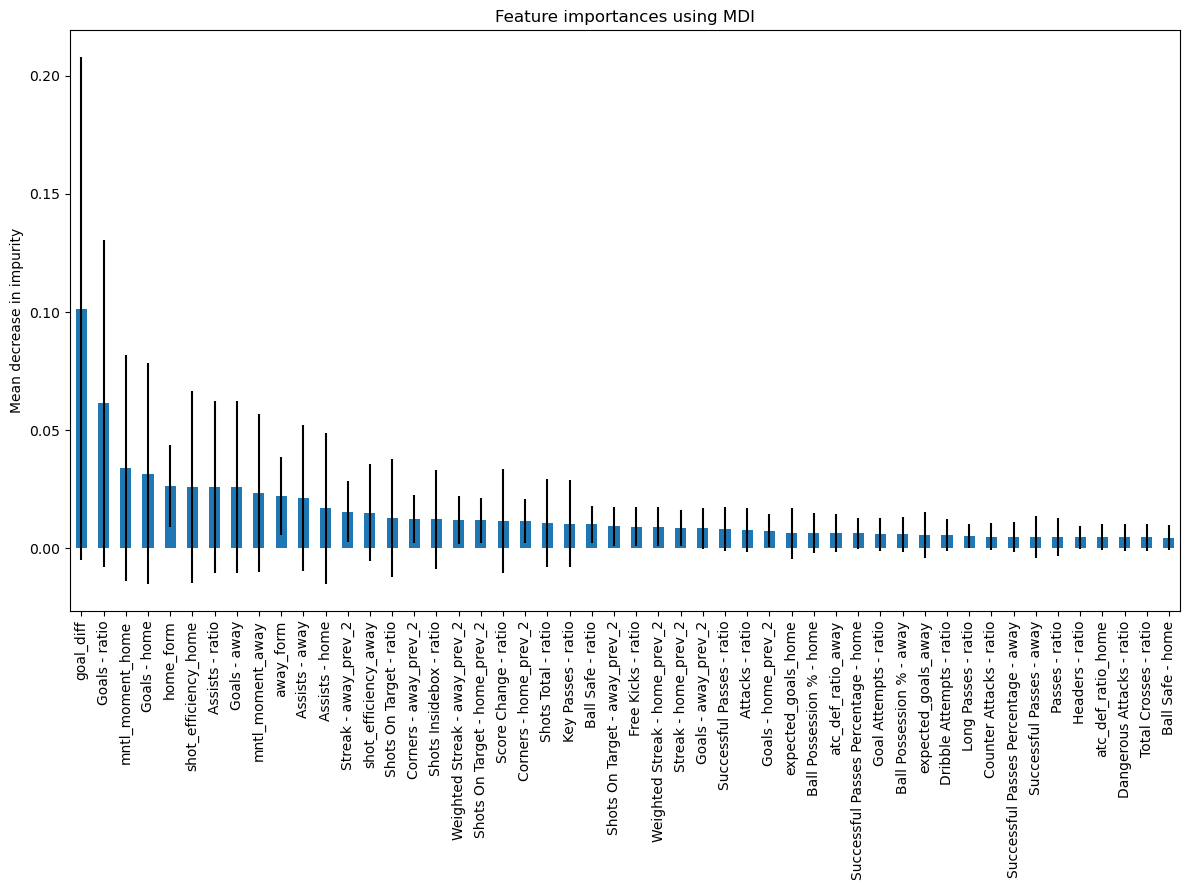

In [ ]:
feature_name_arr = X_train_v1_df.drop(['result', 'match_start_datetime'], axis=1).columns
importance_ser = pd.Series(importance_arr, index=feature_name_arr).sort_values(ascending=False)[:50]

fig, ax = plt.subplots(figsize=(12, 9))
importance_ser.plot.bar(yerr=imp_std_ser.loc[importance_ser.index], ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [ ]:
# Permutation Importance
perm_imp_arr = permutation_importance(
    best_rf_class_v1, test_df.drop(drop_cols_v1 + ['result', 'match_start_datetime'], axis=1), test_df['result'],
    n_repeats=10, random_state=4, n_jobs=2
)

In [ ]:
rf_perm_imp_ser = pd.Series(perm_imp_arr.importances_mean, index=feature_name_arr).sort_values(ascending=False)[:50]
perm_std_ser = pd.Series(perm_imp_arr.importances_std, index=feature_name_arr).loc[rf_perm_imp_ser.index]

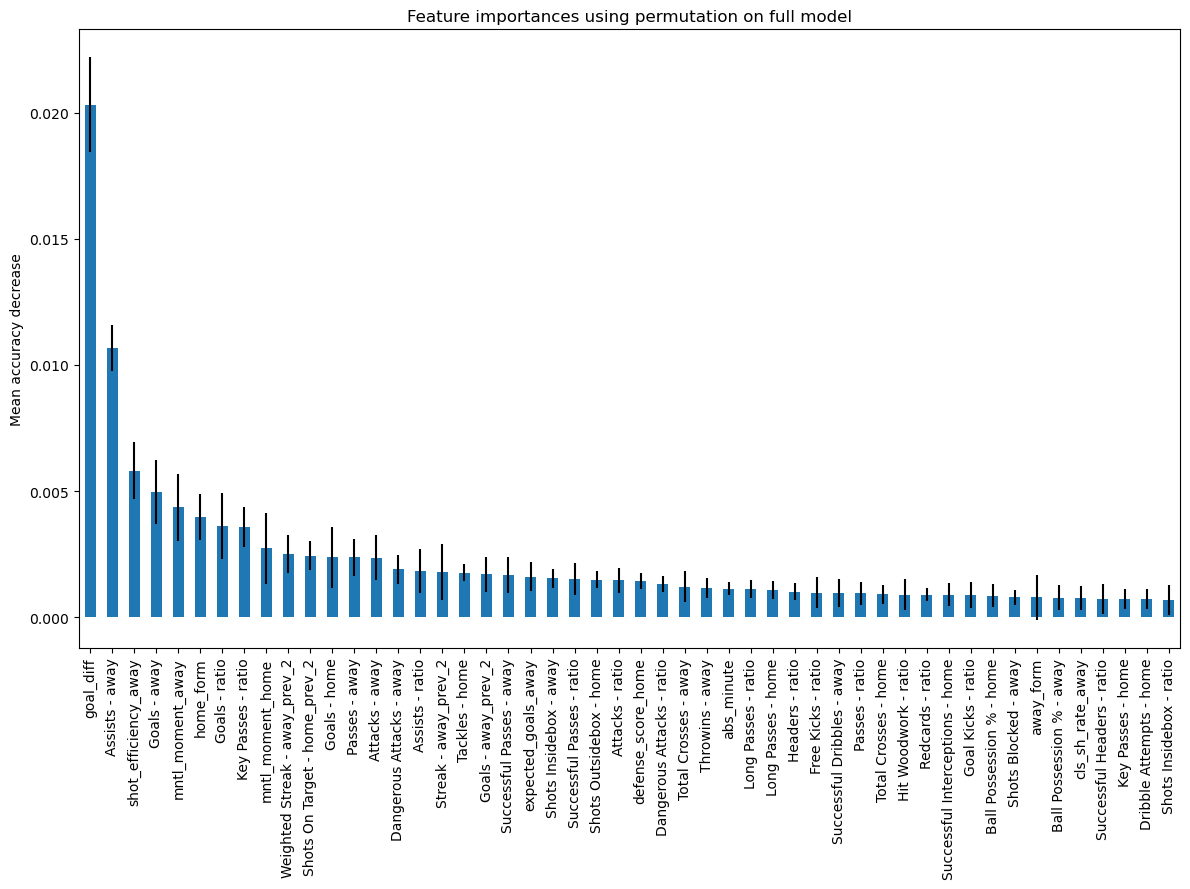

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
rf_perm_imp_ser.plot.bar(yerr=perm_std_ser, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()